In [3]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

Uppgift 1

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(100,)
(100,)


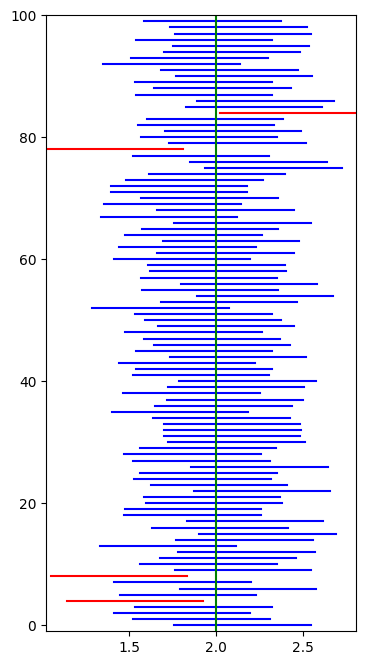

In [ ]:
## Problem 1: Simulering av konfidensintervall

# Parametrar

# Antal mätningar

n = 25
# Väntevärdet
mu = 2
# Standardavvikelsen
sigma = 1
# Ett minus konfidensgraden
alpha = 0.05
# Antal intervall
m = 100
# Simulera n observationer för varje intervall.
x = stats.norm.rvs(loc=mu, scale=sigma, size=(m, n))
# Skatta mu med medelvärdet.
xbar = np.mean(x, axis=-1)
# Beräkna kvantilerna och standardavvikelsen för
# medelvärdet.
lambda_alpha_2 = stats.norm.ppf(1 - alpha / 2)
D = sigma / np.sqrt(n)
# Beräkna undre och övre gränserna.
undre = xbar - lambda_alpha_2 * D
övre = xbar + lambda_alpha_2 * D

## Problem 1: Simulering av konfidensintervall (forts.)
# Skapa en figur med storlek 4 × 8 tum.
plt.figure(figsize=(4, 8))
# Rita upp alla intervall
for k in range(m):
    # Rödmarkera alla intervall som missar mu.
    if övre[k] < mu or undre[k] > mu:
        color = "r"
    else:
        color = "b"
    plt.plot([undre[k], övre[k]], [k, k], color)
# Fixa till gränserna så att figuren ser lite bättre ut.
b_min = np.min(undre)

b_max = np.max(övre)
plt.axis([b_min, b_max, -1, m])
# Rita ut det sanna värdet.
plt.plot([mu, mu], [-1, m], "g")
# Visa plotten.
plt.show()


Uppgift 2

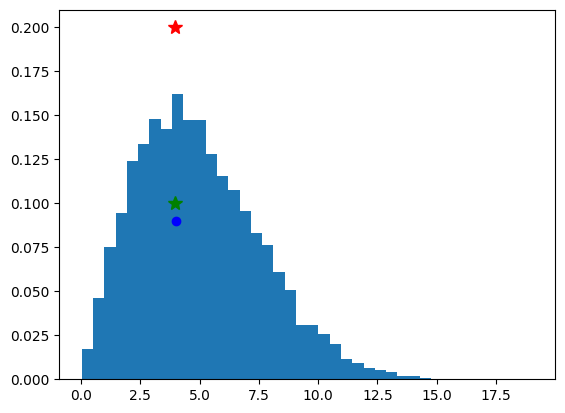

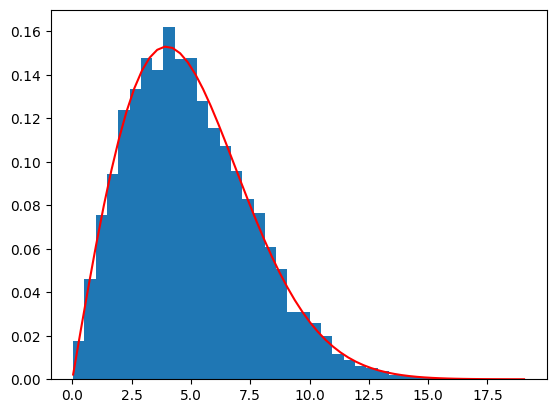

In [5]:


## Problem 2: Maximum likelihood, minsta kvadrat
M = 10000
b = 4
# Simulera M utfall med parameter b.
x = stats.rayleigh.rvs(scale=b, size=M)
# Skapa figur och plotta histogrammet.
plt.figure()
plt.hist(x, 40, density=True)
est_ml = np.sqrt((1 / (2 * M)) * np.sum(x**2))  # Skriv din ML-skattning här
est_mk = (np.mean(x)) / (np.sqrt(np.pi / 2))  # Skriv din MK-skattning här
# Plotta de två skattningarna.
plt.plot(est_mk, 0.1, "g*", markersize=10)
plt.plot(est_ml, 0.2, "r*", markersize=10)
plt.plot(b, 0.09, "bo")
plt.show()

## Problem 2: Maximum likelihood, minsta kvadrat (forts.)
# Skapa figur.
plt.figure()
# Visa histogrammet.
plt.hist(x, 40, density=True)
# Plotta täthetsfunktionen för den skattade parametern.
x_grid = np.linspace(np.min(x), np.max(x), 60)
pdf = stats.rayleigh.pdf(x_grid, scale=est_ml)
plt.plot(x_grid, pdf, "r")
plt.show()


Uppgift 3

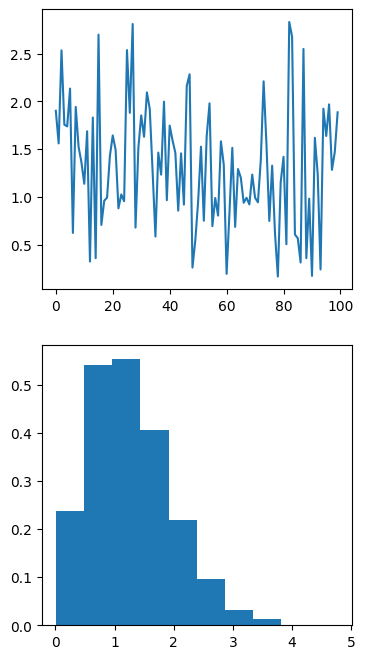

In [32]:
import scipy.io

# ...existing code...

## Problem 3: Konfidensintervall for Rayleighfordelning
y = scipy.io.loadmat("wave_data.mat")["y"].squeeze()

# Plotta en bit av signalen samt histogrammet.
plt.figure(figsize=(4, 8))

plt.subplot(2, 1, 1)
plt.plot(y[:100])
plt.subplot(2, 1, 2)

plt.hist(y,density=True)

plt.show()

In [31]:
est = np.sqrt(np.sum(y ** 2) / (2 * len(y)))  # ✅ RÄTT!

alpha = 0.05
z = stats.norm.ppf(1 - alpha / 2)
SE = est / np.sqrt(2*len(y))
lower_bound = est - z * SE
upper_bound = est + z * SE
print(f"b_hat = {est:.3f}")
print(f"Konfidensintervall: ({lower_bound:.3f}, {upper_bound:.3f})")


b_hat = 1.020
Konfidensintervall: (1.006, 1.035)


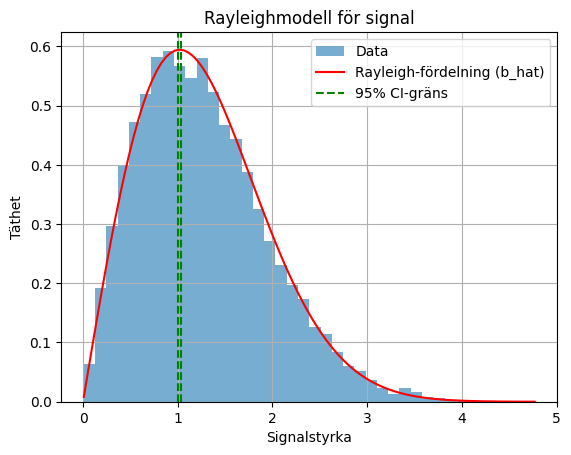

In [33]:
plt.figure()

# Histogram
plt.hist(y, bins=40, density=True, alpha=0.6, label='Data')

# Täthetsfunktion med skattat b
x_grid = np.linspace(np.min(y), np.max(y), 100)
pdf = stats.rayleigh.pdf(x_grid, scale=est)
plt.plot(x_grid, pdf, 'r', label='Rayleigh-fördelning (b_hat)')

# Konfidensintervall (markera med gröna linjer)
plt.axvline(lower_bound, color='green', linestyle='--', label='95% CI-gräns')
plt.axvline(upper_bound, color='green', linestyle='--')

plt.title('Rayleighmodell för signal')
plt.xlabel('Signalstyrka')
plt.ylabel('Täthet')
plt.legend()
plt.grid(True)
plt.show()


Uppgift 4

In [34]:
birth = np.loadtxt("birth.dat")

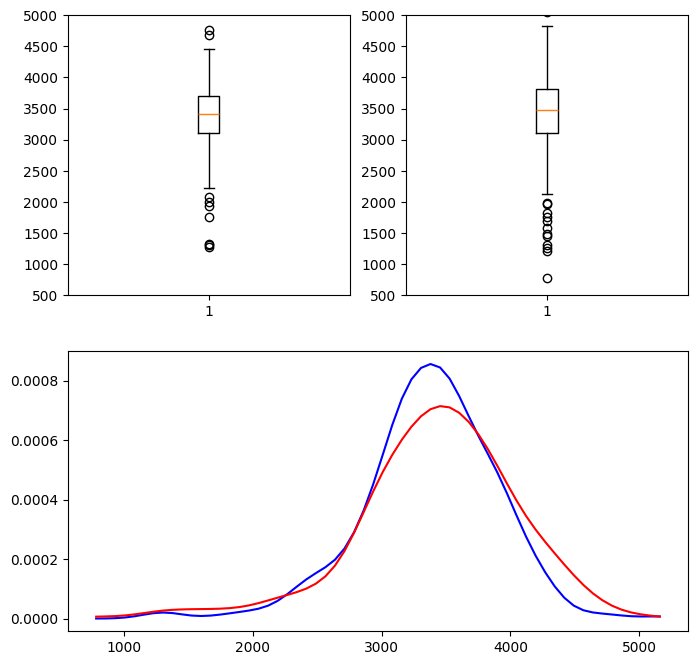

In [ ]:
# Definiera filter beroende på om modern röker (kolonn 20
# är 3) eller inte (kolonn 20 är 1 eller 2). Notera att
# eftersom indexering i Python börjar med noll så betecknas
# kolonn 20 med indexet 19.


non_smokers = (birth[:, 19] < 3)
smokers = (birth[:, 19] == 3)

boys = (birth[:, 1] == 1)
girls = (birth[:, 1] == 2)

# Extrahera födelsevikten (kolonn 3) för de två kategorierna.
x_1 = birth[non_smokers, 2]
y_1 = birth[smokers, 2]

x_2 = birth[boys, 2]
y_2 = birth[girls, 2]

weights = birth[:, 2]


## Problem 4: Fördelningar av givna data (forts.)
# Skapa en stor figur.
plt.figure(figsize=(8, 8))
# Plotta ett låddiagram över x.
plt.subplot(2, 2, 1)
plt.boxplot(x_2)
plt.axis([0, 2, 500, 5000])

# Plotta ett låddiagram över y.
plt.subplot(2, 2, 2)
plt.boxplot(y_2)
plt.axis([0, 2, 500, 5000])
# Beräkna kärnestimator för x och y. Funktionen
# gaussian_kde returnerar ett funktionsobjekt som sedan
# kan evalueras i godtyckliga punkter.
kde_x = stats.gaussian_kde(x_2)
kde_y = stats.gaussian_kde(y_2)
# Skapa ett rutnät för vikterna som vi kan använda för att
# beräkna kärnestimatorernas värden.
min_val = np.min(birth[:, 2])
max_val = np.max(birth[:, 2])
grid = np.linspace(min_val, max_val, 60)
# Plotta kärnestimatorerna.
plt.subplot(2, 2, (3, 4))
plt.plot(grid, kde_x(grid), "b")
plt.plot(grid, kde_y(grid), "r")
plt.show()



Uppgift 5

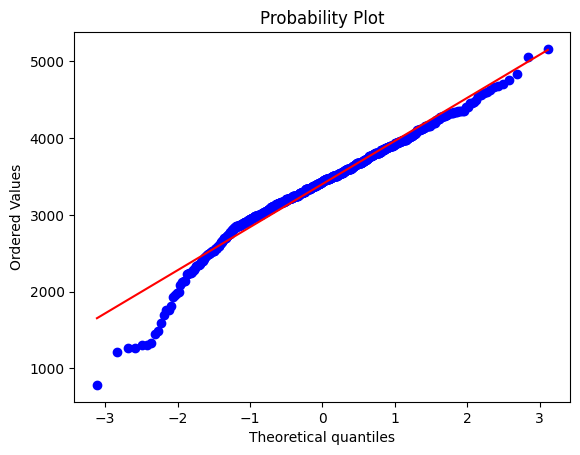

In [43]:
weights = birth[:, 2]
_ = stats.probplot(weights[~np.isnan(weights)], plot=plt)


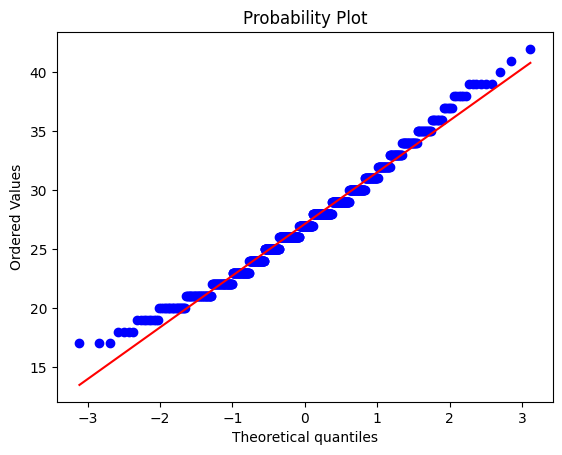

In [44]:
mother_age = birth[:, 3]
mother_age = mother_age[~np.isnan(mother_age)]
_ = stats.probplot(mother_age, plot=plt)

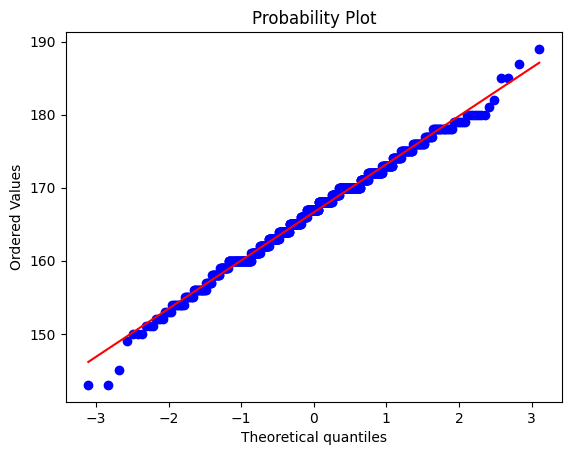

In [45]:
mother_height = birth[:, 15]
mother_height = mother_height[~np.isnan(mother_height)]
_ = stats.probplot(mother_height, plot=plt)

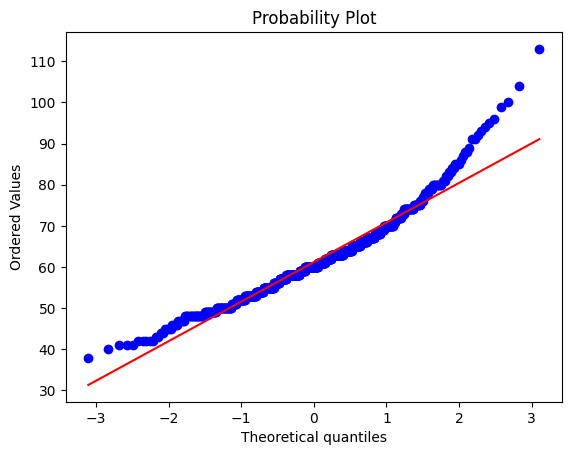

In [46]:
mother_weight = birth[:, 14]
mother_weight = mother_weight[~np.isnan(mother_weight)]
_ = stats.probplot(mother_weight, plot=plt)

In [50]:
from scipy.stats import jarque_bera

weights = birth[:, 2]
weights = weights[~np.isnan(weights)]

result = jarque_bera(weights)

print("Jarque-Bera test")
print(result)
# print(f"JB-statistik: {statistik:.3f}")
# print(f"p-värde: {p_varde:.3f}")

Jarque-Bera test
SignificanceResult(statistic=np.float64(190.5177753024252), pvalue=np.float64(4.26177719213325e-42))


In [52]:
mother_age = birth[:, 3]
mother_age = mother_age[~np.isnan(mother_age)]

result = jarque_bera(mother_age)

print("Jarque-Bera test")
print(result)
# print(f"JB-statistik: {statistik:.3f}")
# print(f"p-värde: {p_varde:.3f}")

Jarque-Bera test
SignificanceResult(statistic=np.float64(18.54130158063342), pvalue=np.float64(9.414722379698738e-05))


Uppgift 6

In [55]:
x_1 = birth[non_smokers, 2]
y_1 = birth[smokers, 2]

weights = birth[:, 2]

mean1 = np.mean(y_1)
mean2 = np.mean(x_1)
s1 = np.std(y_1, ddof=1)
s2 = np.std(x_1, ddof=1)
n1 = len(y_1)
n2 = len(x_1)

diff = mean1 - mean2

SE = np.sqrt(s1**2 / n1 + s2**2 / n2)

df = (s1**2 / n1 + s2**2 / n2)**2 / (
    ((s1**2 / n1)**2) / (n1 - 1) + ((s2**2 / n2)**2) / (n2 - 1)
)

alpha = 0.05
t_crit = stats.norm.ppf(1 - alpha / 2, df)

lower = diff - t_crit * SE
upper = diff + t_crit * SE

t_stat, p_value = stats.ttest_ind(y_1, x_1, equal_var=False)

print(lower, upper)
print(t_stat, p_value)

-18416.0672972981 18126.718497631384
-3.0829299386393862 0.00219646980311006


Uppgift 7

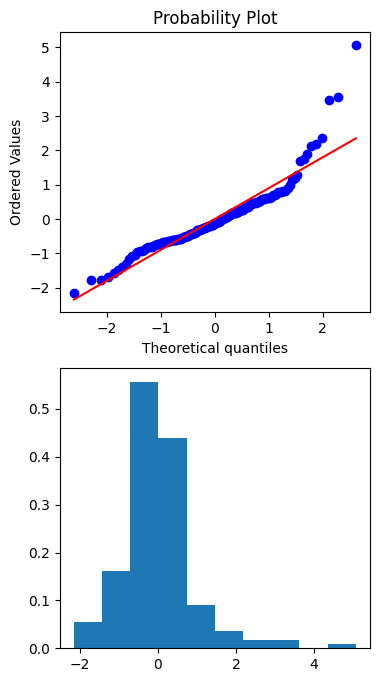

Predikterat antal transistorer år 2025: 1.360e+08


In [57]:
import numpy as np
from tools import regress  

data = np.loadtxt("moore.dat")
t = data[:, 0]         
y = data[:, 1]         
w = np.log(y)  

X = np.c_[np.ones(t.shape[0]), t]  

beta_hat, beta_ci = regress(X, w)


# Prediktion i log-skala
w_hat = X @ beta_hat

# Transformera tillbaka till ursprunglig skala
y_hat = np.exp(w_hat)

## Problem 6: Regression
# Bilda residualerna.
res = w_hat - w
# Skapa figur.
plt.figure(figsize=(4, 8))
# Plotta kvantil–kvantil-plot för residualerna.
plt.subplot(2, 1, 1)
_ = stats.probplot(res, plot=plt)
# Plotta histogram för residualerna.
plt.subplot(2, 1, 2)
plt.hist(res, density=True)
plt.show()

år = 2025
alpha_hat = beta_hat[0]
beta_hat_val = beta_hat[1]

log_y_2025 = alpha_hat + beta_hat_val * år
y_2025 = np.exp(log_y_2025)

print(f"Predikterat antal transistorer år 2025: {y_2025:.3e}")

